### Exploratory Data Analysis

##### Importing Libraries and Loading Data

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
project_root = Path(".").resolve().parent
df = pd.read_parquet(project_root / "data" / "processed" / "london_housing_2008_24.parquet")

In [3]:
fig_dir = project_root /'reports'/'figures'

In [4]:
# Adding Borough Column
raw_dir = project_root / "data" / "raw"
borough_map = {}
for fp in sorted(raw_dir.glob("*_link_*.csv")):
    name = fp.name.split("_link")[0].replace("_", " ")
    lad = pd.read_csv(fp, usecols=["lad23cd"], nrows=1)["lad23cd"].iloc[0]
    borough_map[lad] = name

df["borough"] = df["lad23cd"].map(borough_map)

In [18]:
# Adding Log Floor Area Column
df['log_tfarea'] = np.log10(df['tfarea'])

#### EDA

In [19]:
df

,priceper,year,dateoftransfer,propertytype,duration,price,postcode,lad23cd,transactionid,lmk_key,tfarea,numberrooms,classt,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,CONSTRUCTION_AGE_BAND,month,log_price,borough,log_tfarea
0,1115.384615,1999,1999-10-04,F,L,58000,IG11 0XN,E09000002,{C30CDD8C-3FA0-4259-ABE4-CA992C1AC593},126980681552014061013414193040742,52.0,3.0,12,78,81,England and Wales: 1991-1995,10,4.763428,Barking and Dagenham,1.716003
1,2942.307692,2014,2014-09-26,F,L,153000,IG11 0XN,E09000002,{10382CFD-B786-4103-A1C0-B787ED5944FB},126980681552014061013414193040742,52.0,3.0,12,78,81,England and Wales: 1991-1995,9,5.184691,Barking and Dagenham,1.716003
2,2644.230769,2004,2004-10-29,F,L,137500,IG11 0XN,E09000002,{8276E0B3-FDE3-41F4-8DE5-2E589472C69B},126980681552014061013414193040742,52.0,3.0,12,78,81,England and Wales: 1991-1995,10,5.138303,Barking and Dagenham,1.716003
3,902.884615,1997,1997-01-24,F,L,46950,IG11 0XN,E09000002,{2A289E9D-9E69-CDC8-E050-A8C063054829},126980681552014061013414193040742,52.0,3.0,12,78,81,England and Wales: 1991-1995,1,4.671636,Barking and Dagenham,1.716003
4,4206.349206,2023,2023-11-28,F,L,265000,IG11 7GW,E09000002,{152AB733-B73B-E651-E063-4704A8C061D9},5a6e6b6a24c2a840e15b66b8abcb70c3d09b4096b2f5e2...,63.0,3.0,12,76,79,England and Wales: 1996-2002,11,5.423246,Barking and Dagenham,1.799341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2801038,7920.000000,2014,2014-01-08,T,F,594000,W10 4AS,E09000033,{535389DD-E9D8-4BC1-92E1-FD6D7F14E472},9.4983E+32,75.0,4.0,11,60,80,England and Wales: 1900-1929,1,5.773786,Westminster,1.875061
2801039,12900.013330,2024,2024-07-12,T,F,967501,W10 4AS,E09000033,{2131FCF6-462C-86E8-E063-4804A8C0372B},9.4983E+32,75.0,4.0,11,60,80,England and Wales: 1900-1929,7,5.985651,Westminster,1.875061
2801040,4055.944056,2003,2003-01-30,F,L,174000,W9 3PG,E09000033,{9E9DAC1F-D8D9-4DD2-9F35-EE3E90377051},4.10972E+32,42.9,2.0,11,80,84,England and Wales: 1930-1949,1,5.240549,Westminster,1.632457
2801041,2995.337995,2001,2001-07-20,F,L,128500,W9 3PG,E09000033,{626B9E83-4BD3-420D-BCC0-627A049625E7},4.10972E+32,42.9,2.0,11,80,84,England and Wales: 1930-1949,7,5.108903,Westminster,1.632457


In [20]:
df.describe().round(2)

,priceper,year,dateoftransfer,price,tfarea,numberrooms,classt,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,month,log_price,log_tfarea
count,2801043.00,2801043.00,2801043,2801043.00,2801043.00,2589008.00,2801043.00,2801043.00,2801043.00,2801043.00,2801043.00,2801043.00
mean,4345.65,2008.70,2009-03-22 00:51:01.986266368,375006.45,84.54,3.98,11.30,63.80,76.02,6.69,5.41,1.88
min,0.02,1995.00,1995-01-01 00:00:00,1.00,15.00,0.00,11.00,0.00,0.00,1.00,0.00,1.18
25%,2173.91,2002.00,2002-01-11 00:00:00,154950.00,57.00,3.00,11.00,56.00,72.00,4.00,5.19,1.76
50%,3600.00,2008.00,2008-02-29 00:00:00,255000.00,74.90,4.00,11.00,65.00,78.00,7.00,5.41,1.87
75%,5681.82,2016.00,2016-03-24 00:00:00,445000.00,99.00,5.00,12.00,72.00,83.00,10.00,5.65,2.00
max,340229.09,2024.00,2024-10-31 00:00:00,50000000.00,500.00,99.00,12.00,205.00,207.00,12.00,7.70,2.70
std,3298.72,8.34,NaN,481742.21,43.76,1.72,0.46,12.85,9.98,3.35,0.36,0.19


In [21]:
# Checking Correlation

corr_map = df.corr(numeric_only=True)
corr_map

,priceper,year,price,tfarea,numberrooms,classt,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,month,log_price,log_tfarea
priceper,1.000000,0.626467,0.715754,0.052746,-0.009307,-0.000206,0.127497,0.061768,0.001569,0.752692,0.002980
year,0.626467,1.000000,0.402861,0.052936,0.075576,-0.051449,0.112802,0.160149,-0.029793,0.702134,0.066346
price,0.715754,0.402861,1.000000,0.538277,0.380720,-0.041812,-0.018153,0.002430,-0.001710,0.720980,0.452486
tfarea,0.052746,0.052936,0.538277,1.000000,0.801665,-0.115459,-0.196335,-0.057131,-0.004612,0.489103,0.935167
numberrooms,-0.009307,0.075576,0.380720,0.801665,1.000000,-0.155037,-0.271079,-0.046566,-0.002783,0.401134,0.824199
classt,-0.000206,-0.051449,-0.041812,-0.115459,-0.155037,1.000000,-0.020165,-0.132483,-0.000818,-0.061203,-0.137685
CURRENT_ENERGY_EFFICIENCY,0.127497,0.112802,-0.018153,-0.196335,-0.271079,-0.020165,1.000000,0.588573,0.005024,0.008960,-0.214644
POTENTIAL_ENERGY_EFFICIENCY,0.061768,0.160149,0.002430,-0.057131,-0.046566,-0.132483,0.588573,1.000000,0.002659,0.044531,-0.032789
month,0.001569,-0.029793,-0.001710,-0.004612,-0.002783,-0.000818,0.005024,0.002659,1.000000,0.006215,-0.003228
log_price,0.752692,0.702134,0.720980,0.489103,0.401134,-0.061203,0.008960,0.044531,0.006215,1.000000,0.489326


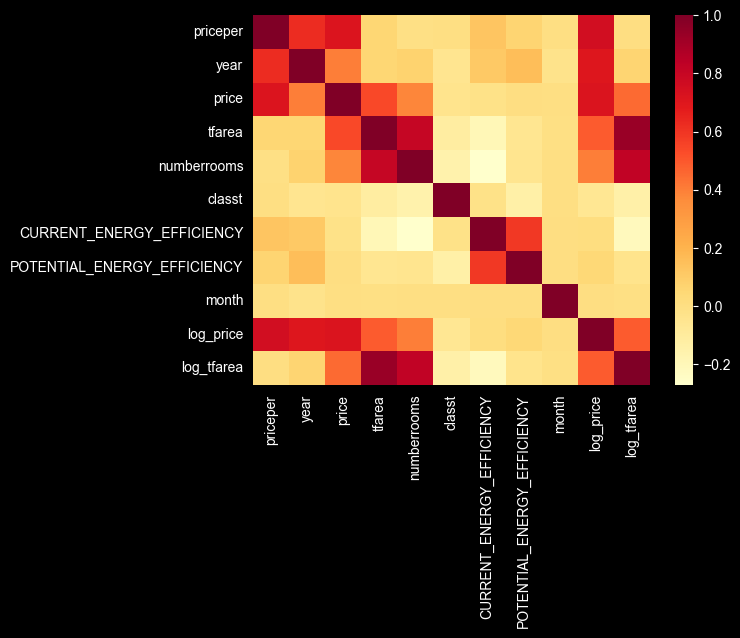

In [22]:
# Correlation Heatmap

sns.heatmap(corr_map, annot=False, cmap="YlOrRd")
plt.show()

In [23]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price                          1.000000
log_price                      0.720980
priceper                       0.715754
tfarea                         0.538277
log_tfarea                     0.452486
year                           0.402861
numberrooms                    0.380720
POTENTIAL_ENERGY_EFFICIENCY    0.002430
month                         -0.001710
CURRENT_ENERGY_EFFICIENCY     -0.018153
classt                        -0.041812
Name: price, dtype: float64

In [24]:
df.corr(numeric_only=True)['log_price'].sort_values(ascending=False)

log_price                      1.000000
priceper                       0.752692
price                          0.720980
year                           0.702134
log_tfarea                     0.489326
tfarea                         0.489103
numberrooms                    0.401134
POTENTIAL_ENERGY_EFFICIENCY    0.044531
CURRENT_ENERGY_EFFICIENCY      0.008960
month                          0.006215
classt                        -0.061203
Name: log_price, dtype: float64

In [25]:
# Missing Values

df.isna().sum()

priceper                            0
year                                0
dateoftransfer                      0
propertytype                        0
duration                            0
price                               0
postcode                            0
lad23cd                             0
transactionid                       0
lmk_key                             0
tfarea                              0
numberrooms                    212035
classt                              0
CURRENT_ENERGY_EFFICIENCY           0
POTENTIAL_ENERGY_EFFICIENCY         0
CONSTRUCTION_AGE_BAND               0
month                               0
log_price                           0
borough                             0
log_tfarea                          0
dtype: int64

##### Price vs Log Price

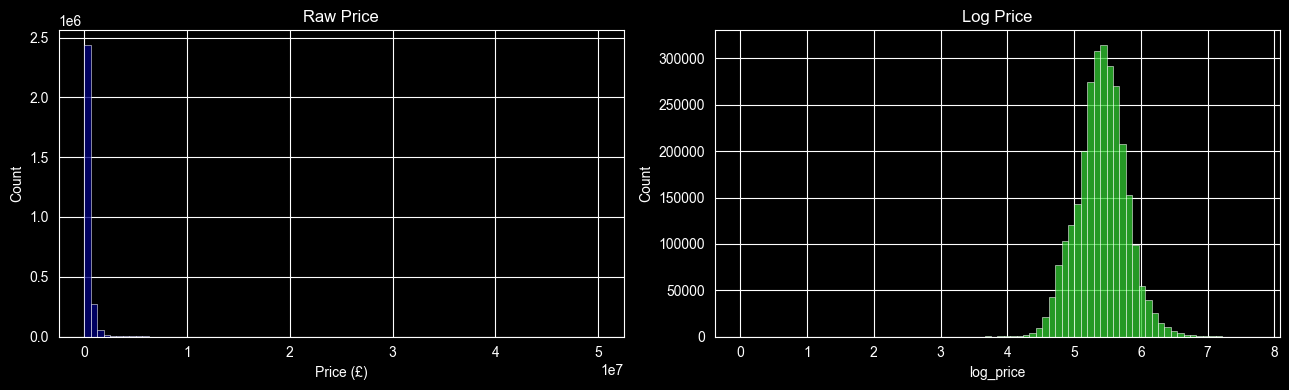

In [10]:
# Raw Price is right skewed so we log transformed it

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['price'], ax=ax[0], bins=80, color='navy')
ax[0].set_title('Raw Price')
ax[0].set_xlabel('Price (£)')

sns.histplot(df['log_price'], ax=ax[1], bins=80, color='limegreen')
ax[1].set_title('Log Price')

plt.savefig(fig_dir / "price_log_price.png", dpi=120, bbox_inches="tight")

plt.tight_layout()
plt.show()

##### Floor Area vs Price

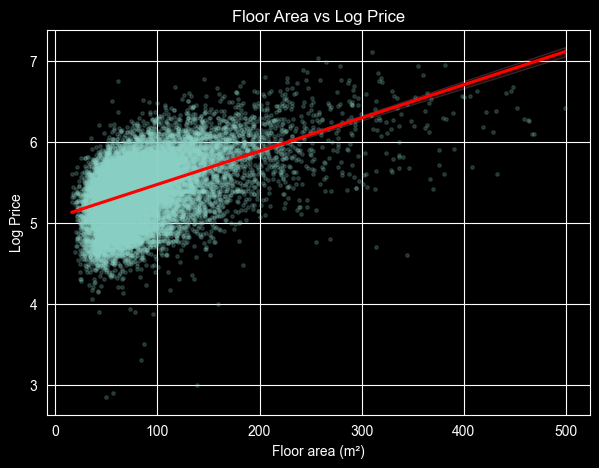

In [11]:
# Floor Area is the strong predictor of Price

sample = df.sample(20_000, random_state=42)

plt.figure(figsize=(7, 5))
sns.regplot(data=sample, x="tfarea", y="log_price",
            scatter_kws={"s": 6, "alpha": 0.2}, line_kws={"color": "red"})
plt.title("Floor Area vs Log Price")
plt.xlabel("Floor area (m²)")
plt.ylabel("Log Price")

plt.savefig(fig_dir / "floor_area_vs_price.png", dpi=120, bbox_inches="tight")

plt.show()

##### Median Price over Time

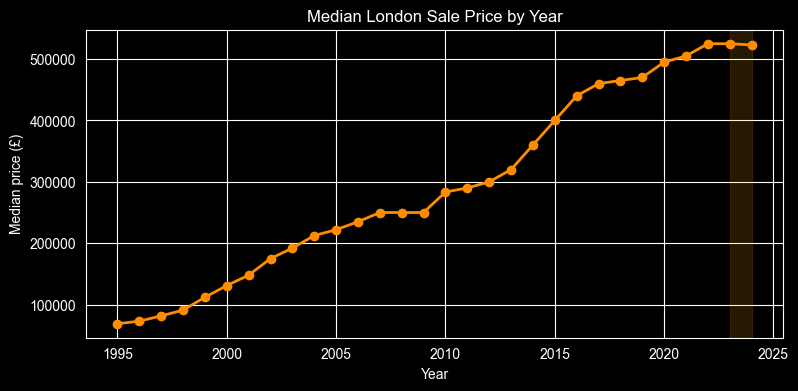

In [12]:
# There is a strong yearly upwards price trend so we need to do a Temporal Split instead of a Random one because random split
# would let the model see future prices resulting in leakage

yearly = df.groupby("year")["price"].median()

plt.figure(figsize=(9, 4))
plt.plot(yearly.index, yearly.values, marker="o", linewidth=2, color="darkorange")
plt.axvspan(2023, 2024, color="orange", alpha=0.15)
plt.title("Median London Sale Price by Year")
plt.xlabel("Year")
plt.ylabel("Median price (£)")

plt.savefig(fig_dir / "price_trend.png", dpi=120, bbox_inches="tight")

plt.show()

##### Prices by Borough

In [13]:
borough_median = df.groupby('borough')["price"].median().sort_values()

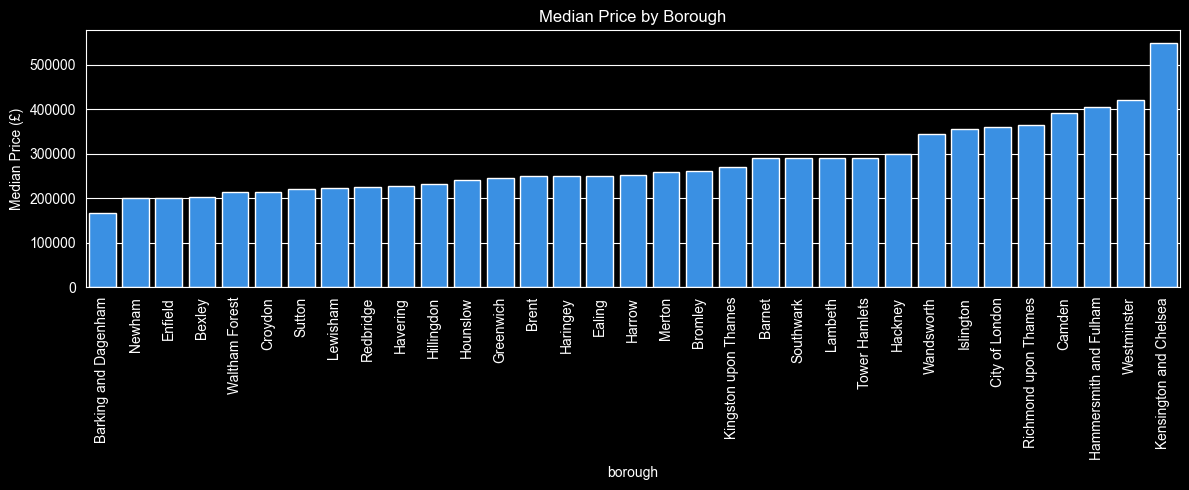

In [14]:
# Exploring House Prices by Borough

plt.figure(figsize=(12, 5))
sns.barplot(x=borough_median.index, y=borough_median.values, color='dodgerblue')

plt.title('Median Price by Borough')
plt.ylabel('Median Price (£)')
plt.xticks(rotation=90)

plt.savefig(fig_dir / "price_median_borough.png", dpi=120, bbox_inches="tight")

plt.tight_layout()
plt.show()

##### Property Type and Tenure

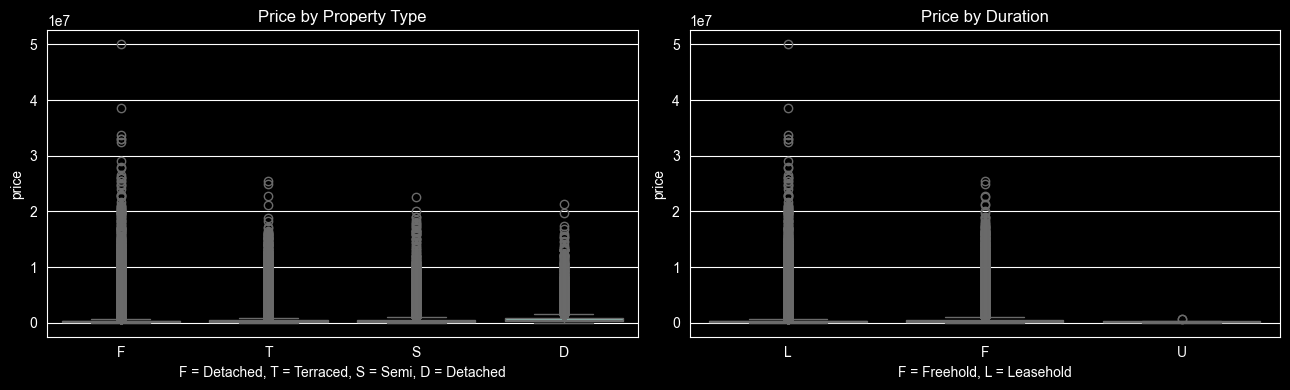

<Figure size 640x480 with 0 Axes>

In [27]:
# Exploring House Prices by the Type of Property and Tenure

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = df.groupby('propertytype')['price'].median().sort_values().index
sns.boxplot(data=df, x="propertytype", y="price", order=order, ax=axes[0])
axes[0].set_title('Price by Property Type')
axes[0].set_xlabel('F = Detached, T = Terraced, S = Semi, D = Detached')

sns.boxplot(data=df, x='duration', y='price', ax=axes[1])
axes[1].set_title('Price by Duration')
axes[1].set_xlabel('F = Freehold, L = Leasehold')

plt.tight_layout()
plt.show()

plt.savefig(fig_dir / "price_duration_type.png", dpi=120, bbox_inches="tight")

##### Construction Age and EPC

In [28]:
df['age_year'] = df['CONSTRUCTION_AGE_BAND'].str.extract(r"(\d{4})").astype(float)

In [29]:
age = (df.dropna(subset=['age_year'])
         .groupby('age_year')
         .agg(n=('price', 'size'),
              med_price=('price', 'median'),
              med_energy=('CURRENT_ENERGY_EFFICIENCY', 'median'))
         .query('n >= 2000'))

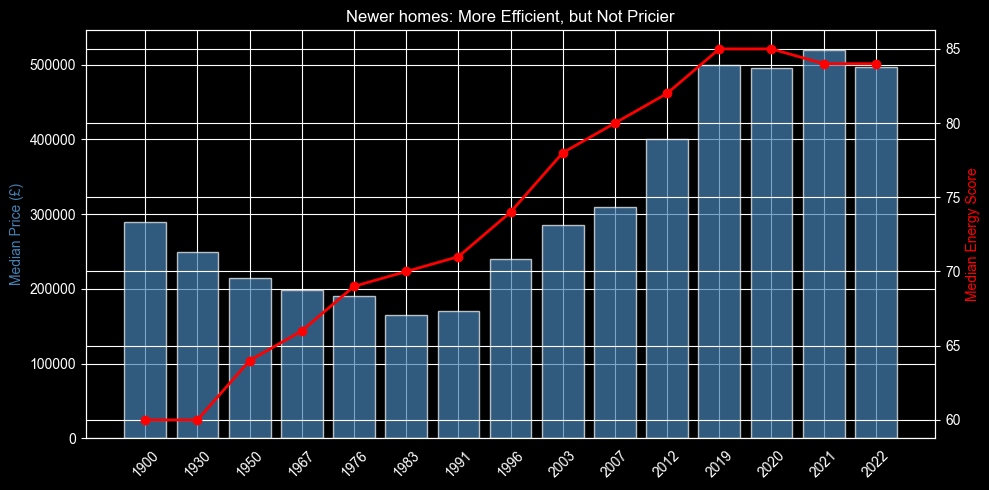

<Figure size 640x480 with 0 Axes>

In [31]:
# Exploring Construction Age and EPC

fig, ax1 = plt.subplots(figsize=(10, 5))
x = range(len(age))

ax1.bar(x, age['med_price'], color='steelblue', alpha=0.7)
ax1.set_ylabel('Median Price (£)', color='steelblue')
ax1.set_xticks(list(x))
ax1.set_xticklabels(age.index.astype(int), rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, age['med_energy'], color='red', marker='o', linewidth=2)
ax2.set_ylabel('Median Energy Score', color='red')

plt.title("Newer homes: More Efficient, but Not Pricier")
plt.tight_layout()
plt.show()

plt.savefig(fig_dir/'price_energy_age.png', dpi=120, bbox_inches="tight")

In [32]:
# Saving DataFrame

processed_dir = project_root /"data" /"processed"
out_path = processed_dir/'london_housing_v2.parquet'
df.to_parquet(out_path, index=False)